In [1]:
import pandas as pd # manipulasi dan analisis data
pd.options.mode.chained_assignment = None # menonaktifkan peringatan
import numpy as np # untuk komputasi numerik
seed = 0
np.random.seed(seed) # mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt # visualisasi data
import seaborn as sns # visualisasi data statistik
from sklearn.metrics import accuracy_score

import datetime as dt # manipulasi data waktu dan tanggal
import re
import string
from nltk.tokenize import word_tokenize # tokenisasi teks
from nltk.corpus import stopwords # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud # membuat visualisasi berbentuk awalan kata

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.0 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# Load Data
df_data = pd.read_csv('tokopedia_product_reviews_2025.csv')
df_data.head()

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


In [3]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   26749 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


In [4]:
# Mengecek missing value
print("Jumlah missing value pada setiap kolom:")
df_data.isnull().sum()

Jumlah missing value pada setiap kolom:


,0
review_text,0
review_date,0
review_id,0
product_name,0
product_category,0
product_variant,38794
product_price,0
product_url,0
product_id,0
rating,0


In [5]:
# Mengisi missing value di kolom product_variant dengan teks default
df_data['product_variant'] = df_data['product_variant'].fillna('Tidak Ada Varian')

# Cek lagi apakah sudah berhasil
print(df_data.isnull().sum())

review_text         0
review_date         0
review_id           0
product_name        0
product_category    0
product_variant     0
product_price       0
product_url         0
product_id          0
rating              0
sold_count          0
shop_id             0
sentiment_label     0
dtype: int64


In [6]:
print("Jumlah dupikat pada setiap kolom:")
df_data.duplicated().sum()

Jumlah dupikat pada setiap kolom:


np.int64(0)

In [7]:
# Menangani Missing value
clean_df = df_data.dropna()

In [8]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  object
 4   product_category  65543 non-null  object
 5   product_variant   65543 non-null  object
 6   product_price     65543 non-null  int64 
 7   product_url       65543 non-null  object
 8   product_id        65543 non-null  int64 
 9   rating            65543 non-null  int64 
 10  sold_count        65543 non-null  int64 
 11  shop_id           65543 non-null  int64 
 12  sentiment_label   65543 non-null  object
dtypes: int64(6), object(7)
memory usage: 6.5+ MB


In [9]:
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git
!pip install python-Levenshtein

  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-73s31ber
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-73s31ber
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
  Created wheel for mpstemmer: filename=mpstemmer-0.1.0-py3-none-any.whl size=99799 sha256=528254d7d933f8906f6a9ebc9e87bdd226cd67bf3c9aaef77e38e3145ff8265c
  Stored in directory: /tmp/pip-ephem-wheel-cache-hztt_4ng/wheels/85/1f/78/fccc1e7e90613593e0a66304a3711d678e3013034d91534182
Successfully built mpstemmer
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.8 MB/s eta 0:00:00


In [10]:
# Processing

import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from mpstemmer import MPStemmer

mps = MPStemmer()


def cleaningText(text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
  text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
  text = re.sub(r'RT[\s]', '', text) # menghapus RT
  text = re.sub(r"http\S+", '', text) # menghapus link
  text = re.sub(r'[0-9]+', '', text) # menghapus angka
  text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

  text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
  text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
  text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
  return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
   text = word_tokenize(text)
   return text

def filteringText(text): # Menghapus stopwords dalam teks
   listStopwords = set(stopwords.words('indonesian'))
   listStopwords1 = set(stopwords.words('english'))
   listStopwords.update(listStopwords1)
   listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
   filtered = []
   for txt in text:
    if txt not in listStopwords:
       filtered.append(txt)
   return filtered

def stemmingText(text):
    return mps.stem_kalimat(text)

def toSentence(list_words): # Mengubah daftar kata menjadi kalima
 sentence = ' '.join(word for word in list_words)
 return sentence

slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal",
              "tpi":"tapi","tp":"tapi","ktolong":"ka tolong","g":"tidak","anjiiiing":"umpat","knp":"kenapa","tibatiba":"tiba-tiba","ad":"ada",
              "tbtb":"tiba-tiba","yt":"youtube","ig":"instagram","gk":"tidak","yg":"yang","moga":"semoga","pake":"pakai","ngirim":"kirim",
              "muas":"puas","sdh":"sudah","lg":"lagi","sya":"saya","klo":"kalau","knpa":"kenapa","tdk":"tidak","sampe":"sampai","kayak":"seperti",
              "cuman":"hanya","prose":"proses","ny":"","jd":"jadi","dgn":"dengan","jg":"juga","tf":"transfer","sampe":"sampai","ngirim":"kirim",
              "bagu":"bagus","skrg":"sekarang","nunggu":"tunggu","udah":"sudah","uda":"sudah","pk":"pakai","@": "di", "abis": "habis", "wtb": "beli",
              "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia",
              "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah",
              "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku",
              "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa",
              "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik",
              "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang",
              "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur",
              "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar",
              "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana",
              "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar",
              "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng",
              "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur",
              "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi",
              "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja",
              "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci",
              "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor",
              "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan",
              "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan",
              "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian",
              "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile",
              "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan",
              "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi",
              "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda",
              "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo",
              "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh",
              "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi",
              "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus",
              "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah",
              "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba",
              "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras",
              "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual","gw": "saya","tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
      if word.lower() in slangwords:
        fixed_words.append(slangwords[word.lower()])
      else:
        fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [11]:

# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['review_text'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# STEMMING
clean_df['text_stemming'] = clean_df['text_slangwords'].apply(stemmingText)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_stemming'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [12]:
clean_df

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label,text_clean,text_casefoldingText,text_slangwords,text_stemming,text_tokenizingText,text_stopword,text_akhir
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive,baru sekali ini terima brg dr belanja online d...,baru sekali ini terima brg dr belanja online d...,baru sekali ini terima bareng dr belanja onlin...,baru sekali ini terima bareng dr belanja onlin...,"[baru, sekali, ini, terima, bareng, dr, belanj...","[terima, bareng, dr, belanja, online, dg, pack...",terima bareng dr belanja online dg packing sup...
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive,cocok bgt aku sama telur nya nga Amis menurutk...,cocok bgt aku sama telur nya nga amis menurutk...,cocok banget aku sama telur nya nga amis menur...,cocok banget aku sama telur nya tidak amis tur...,"[cocok, banget, aku, sama, telur, nya, tidak, ...","[cocok, banget, telur, amis, neg, terima, aman...",cocok banget telur amis neg terima aman terima...
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive,Telornya sudah sampai di rumah dengan kemasan ...,telornya sudah sampai di rumah dengan kemasan ...,telornya sudah sampai di rumah dengan kemasan ...,telor sudah sampai di rumah dengan kemas yang ...,"[telor, sudah, sampai, di, rumah, dengan, kema...","[telor, rumah, kemas, rapi, terimakasih, selle...",telor rumah kemas rapi terimakasih sellernya m...
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive,Telor sudah diterima dengan baik dan tidak ada...,telor sudah diterima dengan baik dan tidak ada...,telor sudah diterima dengan baik dan tidak ada...,telor sudah terima dengan baik dan tidak ada y...,"[telor, sudah, terima, dengan, baik, dan, tida...","[telor, terima, pecah, terimakasih, ller]",telor terima pecah terimakasih ller
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive,Alhamdulillah penjual amanahTelor nya terbaiks...,alhamdulillah penjual amanahtelor nya terbaiks...,alhamdulillah penjual amanahtelor nya terbaiks...,alhamdulillah jual amanahtelor nya terbaikseda...,"[alhamdulillah, jual, amanahtelor, nya, terbai...","[alhamdulillah, jual, amanahtelor, terbaikseda...",alhamdulillah jual amanahtelor terbaiksedap le...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65538,"kwalitas bagus, pokoknya rekomendit deh",2025-01-06,1139605415,SPEEDS Bola Voli Voley Voli Size 5 Volleyball ...,Olahraga,-1 BIRU,68000,https://www.tokopedia.com/speedsofficial/speed...,15686645897,5,90,3851982,positive,kwalitas bagus pokoknya rekomendit deh,kwalitas bagus pokoknya rekomendit deh,kwalitas bagus pokoknya rekomendit deh,kwalitas bagus pokok rekomendit deh,"[kwalitas, bagus, pokok, rekomendit, deh]","[kwalitas, bagus, pokok, rekomendit, deh]",kwalitas bagus pokok rekomendit deh
65539,Sesuai harga,2025-05-08,1441659919,SPEEDS Bola Voli Voley Voli Size 5 Volleyball ...,Olahraga,Tidak Ada Varian,68000,https://www.tokopedia.com/speedsoffic

In [13]:
# Pelabelan

import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [14]:
def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:

    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score > 0):
      polarity = 'positive'
      # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
      polarity = 'negative'
      # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif

    else:
      polarity = 'neutral'
      # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [15]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    48472
negative    10324
neutral      6747
Name: count, dtype: int64


In [16]:
# Menyimpan data ke file CSV
clean_df.to_csv('fix_tokopedia_reviews.csv', index=False)

print("Data berhasil disimpan ke CSV!")

Data berhasil disimpan ke CSV!


**VISUALISASI**

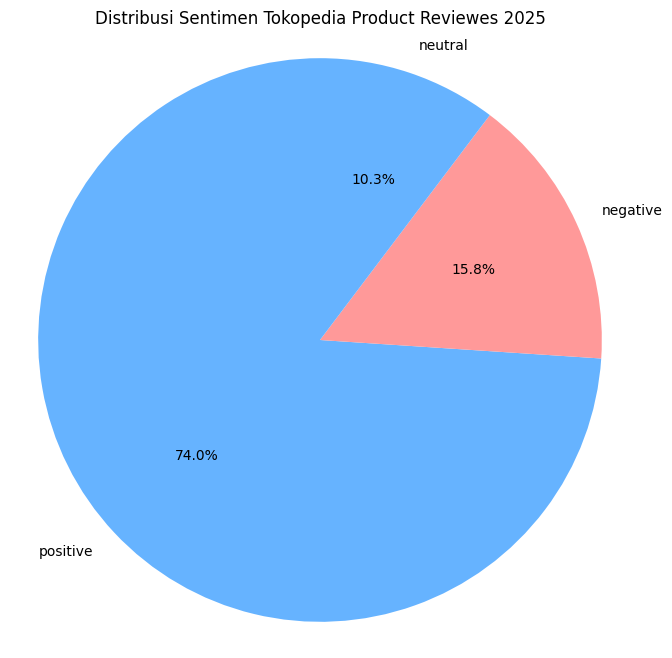

In [17]:
# Menghitung jumlah masing-masing polaritas
sentiment_counts = clean_df['polarity'].value_counts()

# Membuat pie chart
fig = plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Distribusi Sentimen Tokopedia Product Reviewes 2025')
plt.axis('equal') # Memastikan pie chart berbentuk lingkaran sempurna
plt.show()

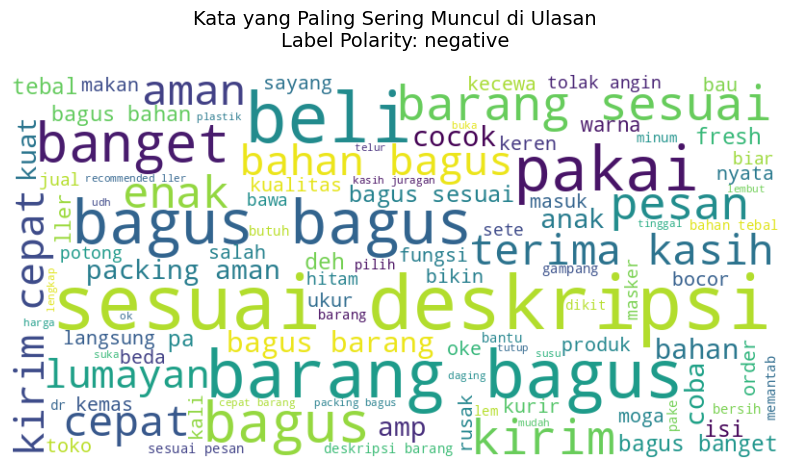

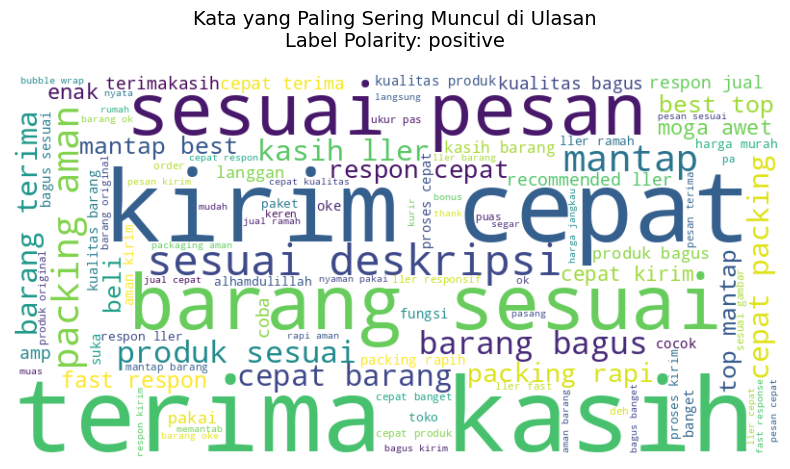

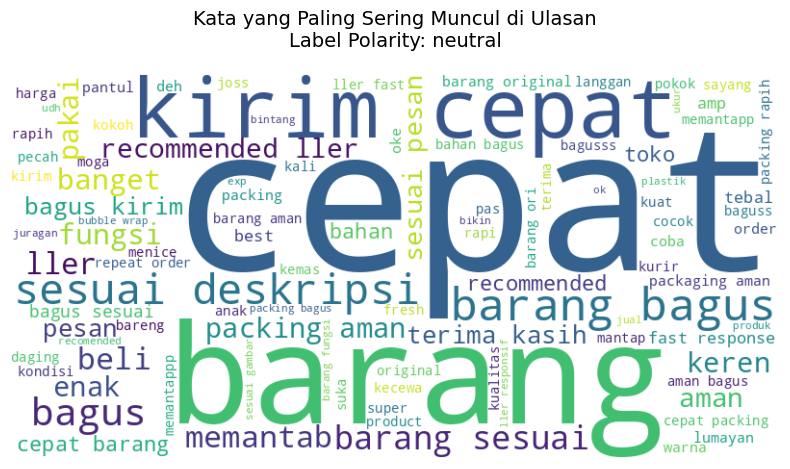

In [18]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Mendapatkan daftar label unik yang ada di kolom 'polarity' (misal: positif, negatif)
daftar_label = clean_df['polarity'].unique()

# Melakukan perulangan untuk setiap label
for label in daftar_label:

    # 1. Filter dataframe hanya untuk label polarity yang sedang diproses
    subset_df = clean_df[clean_df['polarity'] == label]

    # 2. Menggabungkan semua teks bersih pada label tersebut menjadi satu string besar
    text_per_label = ' '.join(subset_df['text_akhir'].astype(str))

    # Memastikan ada teks sebelum membuat wordcloud (menghindari error jika data kosong)
    if len(text_per_label.strip()) > 0:
        # 3. Membuat WordCloud
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='viridis',
            max_words=100
        ).generate(text_per_label)

        # 4. Menampilkan gambar
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        # Judul akan otomatis menampilkan nama label polarity-nya
        plt.title(f"Kata yang Paling Sering Muncul di Ulasan\nLabel Polarity: {label}", fontsize=14, pad=20)
        plt.show()
    else:
        print(f"Tidak ada teks untuk label polarity: {label}")

In [19]:
# Split data
from sklearn.model_selection import train_test_split

X = clean_df['text_akhir'].values
y = clean_df['polarity'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
# Ekstrasi fitur dengan TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=10000, min_df=17, max_df=0.8, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
# Transform pada data testing
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape X_train_tfidf: {X_train_tfidf.shape}")

Shape X_train_tfidf: (52434, 3449)


**MODELLING**

In [33]:
# Model SVM

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']

# Membuat model SVM
svm_model = SVC(kernel='linear', C=1, random_state=42)

# Training model
svm_model.fit(X_train_tfidf, y_train)

print("\n=== 3. Prediksi dan Evaluasi ===")
y_train_pred = svm_model.predict(X_train_tfidf)
y_test_pred  = svm_model.predict(X_test_tfidf)

print(f"Akurasi Training (Data Murni) : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Akurasi Testing  (Data Murni) : {accuracy_score(y_test, y_test_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=target_names))
print(f"Macro F1-Score : {f1_score(y_test, y_test_pred, average='macro'):.4f}")


=== 3. Prediksi dan Evaluasi ===
Akurasi Training (Data Murni) : 0.9537
Akurasi Testing  (Data Murni) : 0.9365

=== Classification Report ===
              precision    recall  f1-score   support

 Negatif (0)       0.88      0.86      0.87      2065
  Netral (1)       0.86      0.69      0.76      1349
 Positif (2)       0.96      0.99      0.97      9695

    accuracy                           0.94     13109
   macro avg       0.90      0.85      0.87     13109
weighted avg       0.93      0.94      0.93     13109

Macro F1-Score : 0.8687


In [22]:
# ============================================================
#  TUNING LinearSVC + TF-IDF dengan GridSearchCV
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score, accuracy_score

target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']

# 1. Masukkan settingan TF-IDF langsung ke dalam Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, min_df=17, max_df=0.8)),
    ('svc', LinearSVC(class_weight='balanced', random_state=42, max_iter=5000, dual="auto"))
])

# 2. Parameter SVM yang akan di-tuning
param_grid = {
    'svc__C': [0.01, 0.1, 1, 10],
    'svc__loss': ['hinge', 'squared_hinge']
}

print("=== Grid Search Full Pipeline sedang berjalan... (harap tunggu) ===")
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"\nParameter terbaik : {grid.best_params_}")
print(f"Macro F1 CV terbaik: {grid.best_score_:.4f}")

# 4. Evaluasi menggunakan model terbaik
best_model = grid.best_estimator_

# PENTING: Prediksi juga menggunakan data teks asli (X_test dan X_train)
y_test_pred2  = best_model.predict(X_test)
y_train_pred2 = best_model.predict(X_train)

print(f"\nAkurasi Training : {accuracy_score(y_train, y_train_pred2):.4f}")
print(f"Akurasi Testing  : {accuracy_score(y_test, y_test_pred2):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred2, target_names=target_names))
print(f"Macro F1-Score   : {f1_score(y_test, y_test_pred2, average='macro'):.4f}")

=== Grid Search Full Pipeline sedang berjalan... (harap tunggu) ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Parameter terbaik : {'svc__C': 10, 'svc__loss': 'hinge'}
Macro F1 CV terbaik: 0.8610

Akurasi Training : 0.9575
Akurasi Testing  : 0.9378

=== Classification Report ===
              precision    recall  f1-score   support

 Negatif (0)       0.83      0.90      0.86      2065
  Netral (1)       0.82      0.69      0.75      1349
 Positif (2)       0.98      0.98      0.98      9695

    accuracy                           0.94     13109
   macro avg       0.87      0.86      0.86     13109
weighted avg       0.94      0.94      0.94     13109

Macro F1-Score   : 0.8633


In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder


x_tf = clean_df['text_akhir'].astype(str)

encoder = LabelEncoder()
y_tf = encoder.fit_transform(clean_df['polarity'])

# 2. Hyperparameter
vocab_size = 10000
embedding_dim = 128
max_length = 100
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"
num_epochs = 10

# 3. Split Data (WAJIB pakai Stratify agar kelas 1.2% terjaga)
X_train_tf, X_test_tf, Y_train_tf, Y_test_tf = train_test_split(
    x_tf,
    y_tf,
    test_size=0.2,
    random_state=42,
    stratify=y_tf
)

# 4. Tokenisasi
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train_tf)

train_sequences = tokenizer.texts_to_sequences(X_train_tf)
test_sequences = tokenizer.texts_to_sequences(X_test_tf)

# 5. Padding
X_train_pad = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
X_test_pad = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# === PENANGANAN IMBALANCE (Class Weight) ===
weights = compute_class_weight('balanced', classes=np.unique(Y_train_tf), y=Y_train_tf)
class_weights_dict = dict(enumerate(weights))

# 6. Membangun Model LSTM
model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 7. Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 8. Training Model
print("Memulai proses training LSTM...")
history = model_lstm.fit(
    X_train_pad,
    Y_train_tf,
    epochs=num_epochs,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights_dict, # Memberi perhatian lebih pada kelas minoritas
    callbacks=[early_stop],
    verbose=1
)

# 9. Evaluasi Model (Deep Analysis)
print("\n--- Hasil Evaluasi Final ---")
y_pred_probs = model_lstm.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
print(classification_report(Y_test_tf, y_pred, target_names=target_names))

final_f1 = f1_score(Y_test_tf, y_pred, average='macro')
print(f"Final Macro F1-Score: {final_f1:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Memulai proses training LSTM...
Epoch 1/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.8243 - loss: 0.5324 - val_accuracy: 0.9059 - val_loss: 0.2429
Epoch 2/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9338 - loss: 0.2343 - val_accuracy: 0.9322 - val_loss: 0.1809
Epoch 3/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9489 - loss: 0.1683 - val_accuracy: 0.9349 - val_loss: 0.1872
Epoch 4/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9626 - loss: 0.1235 - val_accuracy: 0.9290 - val_loss: 0.2118
Epoch 5/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9691 - loss: 0.1023 - val_accuracy: 0.9401 - val_loss: 0.2094

--- Hasil Evaluasi Final ---
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
              precision    recall  f1-score   support

Negative (0)       0.92      0.88      0.90      2065
 Neutral (1)       0.64      0.88      0.74      1349
Positive (2)       0.99      0.95      0.97      9695

    accuracy                 

**TESTING**

In [34]:
import joblib
import tensorflow as tf

# Simpan Model SVM (Pastikan variabelnya sesuai saat kamu training, yaitu svm_model)
# Jika variabelnya bernama lain, silakan diganti.
joblib.dump(svm_model, 'model_svm.pkl')
joblib.dump(best_model, 'model_svm_tuning.pkl')

# Simpan TF-IDF Vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')


# Simpan Model LSTM
model_lstm.save('model_lstm.h5')
# Simpan Keras Tokenizer
joblib.dump(tokenizer, 'lstm_tokenizer.pkl')

print("\nModel dan TF-IDF Vectorizer berhasil disimpan!")


Model dan TF-IDF Vectorizer berhasil disimpan!


In [35]:
import joblib
import pandas as pd
# Tambahkan import metrik evaluasi
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Model dan TF-IDF
model = joblib.load('model_svm.pkl')
tfidf = joblib.load('tfidf_vectorizer.pkl')

# PERBAIKAN: Definisikan label_map di sini
label_map = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}

# 2. Data Testing dan KUNCI JAWABAN (Ground Truth)
data_testing = [
    "Barang cepat sampai, packing aman banget pakai bubble wrap tebal. Mantap!",                 # Positif
    "Aplikasi sering *freeze* pas mau bayar, tolong diperbaiki *bug*-nya!",                      # Negatif
    "Biasa saja, pengiriman standar. Kualitas barang sesuai harga sih.",                         # Netral
    "Kenapa sekarang susah *login* ya? Padahal koneksi internet lancar.",                        # Negatif
    "Terima kasih Tokopedia, dapet *cashback* gede pas *flash sale* tadi pagi!",                 # Positif
    "Seller ramah, barang cepat dikirim, kurir langganan juga amanah."                           # Positif
]

# Array label asli sesuai urutan kalimat di atas (0: Negatif, 1: Netral, 2: Positif)
label_asli = [2, 0, 1, 0, 2, 2]

# 3. Transformasi dan Prediksi
X_new_tfidf = tfidf.transform(data_testing)
hasil_prediksi = model.predict(X_new_tfidf) # This returns string labels like 'positive', 'negative', 'neutral'

# 4. Mapping teks untuk tabel dan konversi untuk evaluasi
# The model's predictions are already in string format ('positive', 'negative', 'neutral')
hasil_sentimen_teks = hasil_prediksi

# To evaluate, we need to convert the string predictions back to numerical labels (0, 1, 2)
# Create a reverse map for evaluation
reverse_label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
hasil_prediksi_numerical = [reverse_label_map[label] for label in hasil_prediksi]


# 5. Menampilkan Tabel Perbandingan (Tebakan vs Asli)
df_hasil = pd.DataFrame({
    'Ulasan': data_testing,
    'Label Asli': [label_map.get(angka, "Unknown") for angka in label_asli], # Use the original label_map for display
    'Prediksi Model': hasil_sentimen_teks # Already in string format
})

print("--- HASIL INFERENSI MODEL SENTIMEN ---")
print(df_hasil.to_string(index=False))
print("\n" + "="*50 + "\n")

# =======================================================
# 6. BAGIAN CEK AKURASI
# =======================================================
# Use hasil_prediksi_numerical for accuracy_score and classification_report
akurasi = accuracy_score(label_asli, hasil_prediksi_numerical)
print(f"Akurasi pada Data Testing Baru : {akurasi * 100:.2f}%\n")

print("=== Classification Report ===")
# Tambahkan target_names agar report-nya lebih enak dibaca
target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print(classification_report(label_asli, hasil_prediksi_numerical, target_names=target_names))

--- HASIL INFERENSI MODEL SENTIMEN ---
                                                                   Ulasan Label Asli Prediksi Model
Barang cepat sampai, packing aman banget pakai bubble wrap tebal. Mantap!    Positif       positive
     Aplikasi sering *freeze* pas mau bayar, tolong diperbaiki *bug*-nya!    Negatif       negative
        Biasa saja, pengiriman standar. Kualitas barang sesuai harga sih.     Netral       positive
       Kenapa sekarang susah *login* ya? Padahal koneksi internet lancar.    Negatif       negative
Terima kasih Tokopedia, dapet *cashback* gede pas *flash sale* tadi pagi!    Positif       positive
         Seller ramah, barang cepat dikirim, kurir langganan juga amanah.    Positif       positive


Akurasi pada Data Testing Baru : 83.33%

=== Classification Report ===
              precision    recall  f1-score   support

 Negatif (0)       1.00      1.00      1.00         2
  Netral (1)       0.00      0.00      0.00         1
 Positif (2)       0.75  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
import joblib
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report

# === Parameter yang digunakan saat training LSTM ===
max_length = 100
padding_type = 'post'
trunc_type = 'post'

# 1. Load Model LSTM dan Keras Tokenizer
model = tf.keras.models.load_model('model_lstm.h5')
tokenizer = joblib.load('lstm_tokenizer.pkl')

# PERBAIKAN 1: Sesuaikan penamaan label agar konsisten dengan output evaluasi
label_map = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}

# 2. Data Testing dan KUNCI JAWABAN (Ground Truth)
data_testing = [
    "Pesanan datang lebih cepat dari estimasi, kualitas produk juga bagus banget. Puas!",            # Positif
    "Aplikasi tiba-tiba keluar sendiri saat checkout, jadi gagal transaksi.",                        # Negatif
    "Barang sudah sampai, sesuai deskripsi. Tidak ada yang spesial sih.",                            # Netral
    "Sudah coba berkali-kali verifikasi OTP tapi tidak masuk juga, bikin kesal.",                    # Negatif
    "Senang banget dapat voucher gratis ongkir dan diskon besar hari ini!",                           # Positif
    "Admin toko responnya cepat dan membantu saat saya tanya detail produk.",                         # Positif
    "Packaging standar, barang aman, pengiriman juga tidak terlalu cepat maupun lambat.",             # Netral
    "Sistem pembayaran error terus, saldo sudah terpotong tapi pesanan belum masuk.",                 # Negatif
    "Produknya original, harga bersaing, dan bonusnya banyak. Recommended!",                          # Positif
    "Kurir datang sesuai jadwal, pelayanan biasa saja tanpa kendala.",                                # Netral
    "Notifikasi aplikasi sering telat masuk sehingga saya ketinggalan promo.",                        # Negatif
    "Belanja di sini selalu memuaskan, proses cepat dan banyak promo menarik."                        # Positif
]

# Array label asli (0: Negatif, 1: Netral, 2: Positif)
label_asli = [2, 0, 1, 0, 2, 2, 1, 0, 2, 1, 0, 2]

# 3. Transformasi data_testing ke urutan token dan padding (sesuai input LSTM)
sequences = tokenizer.texts_to_sequences(data_testing)
X_new_padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# PERBAIKAN 2: Tambahkan verbose=0 agar terminal bersih dari progress bar bawaan Keras
hasil_prediksi_probs = model.predict(X_new_padded, verbose=0)
hasil_prediksi_numerical = np.argmax(hasil_prediksi_probs, axis=1)

# 4. Mapping teks untuk tabel
hasil_sentimen_teks = [label_map.get(angka, "Unknown") for angka in hasil_prediksi_numerical]

# 5. Menampilkan Tabel Perbandingan (Tebakan vs Asli)
df_hasil = pd.DataFrame({
    'Ulasan': data_testing,
    'Label Asli': [label_map.get(angka, "Unknown") for angka in label_asli],
    'Prediksi Model': hasil_sentimen_teks
})

print("--- HASIL INFERENSI MODEL LSTM ---")
print(df_hasil.to_string(index=False))
print("\n" + "="*50 + "\n")

# =======================================================
# 6. BAGIAN CEK AKURASI
# =======================================================
akurasi = accuracy_score(label_asli, hasil_prediksi_numerical)
print(f"Akurasi pada Data Testing Baru : {akurasi * 100:.2f}%\n")

print("=== Classification Report ===")
target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print(classification_report(label_asli, hasil_prediksi_numerical, target_names=target_names))

--- HASIL INFERENSI MODEL LSTM ---
                                                                            Ulasan Label Asli Prediksi Model
Pesanan datang lebih cepat dari estimasi, kualitas produk juga bagus banget. Puas!    Positif        Positif
            Aplikasi tiba-tiba keluar sendiri saat checkout, jadi gagal transaksi.    Negatif        Negatif
                Barang sudah sampai, sesuai deskripsi. Tidak ada yang spesial sih.     Netral         Netral
        Sudah coba berkali-kali verifikasi OTP tapi tidak masuk juga, bikin kesal.    Negatif        Negatif
              Senang banget dapat voucher gratis ongkir dan diskon besar hari ini!    Positif        Positif
            Admin toko responnya cepat dan membantu saat saya tanya detail produk.    Positif        Positif
Packaging standar, barang aman, pengiriman juga tidak terlalu cepat maupun lambat.     Netral        Negatif
    Sistem pembayaran error terus, saldo sudah terpotong tapi pesanan belum masuk.    Negatif

In [43]:
import joblib
import pandas as pd
# Tambahkan import metrik evaluasi
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Model dan TF-IDF
model = joblib.load('model_svm_tuning.pkl')

# PERBAIKAN: Definisikan label_map di sini
label_map = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}

# 2. Data Testing dan KUNCI JAWABAN (Ground Truth)
data_testing = [
    "Barangnya bagus banget, pengiriman super cepat. Puas!",             # Positif
    "Kecewa berat, barang datang dalam kondisi rusak dan tidak nyala.",  # Negatif
    "Barang sudah sampai sesuai pesanan.",                               # Netral
    "Aplikasi sering error pas mau bayar, tolong diperbaiki.",           # Negatif
    "Admin ramah, langsung dikirim hari itu juga. Makasih min!",         # Positif
]

# Array label asli (0: Negatif, 1: Netral, 2: Positif)
label_asli = [2, 0, 1, 0, 2]

# 3. Transformasi dan Prediksi
# PERBAIKAN: Berikan data_testing (teks mentah) langsung ke model.predict()
# Model (pipeline) akan secara internal melakukan TF-IDF dan prediksi.
hasil_prediksi = model.predict(data_testing) # This returns string labels like 'positive', 'negative', 'neutral'

# 4. Mapping teks untuk tabel dan konversi untuk evaluasi
# The model's predictions are already in string format ('positive', 'negative', 'neutral')
hasil_sentimen_teks = hasil_prediksi

# To evaluate, we need to convert the string predictions back to numerical labels (0, 1, 2)
# Create a reverse map for evaluation
reverse_label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
hasil_prediksi_numerical = [reverse_label_map[label] for label in hasil_prediksi]


# 5. Menampilkan Tabel Perbandingan (Tebakan vs Asli)
df_hasil = pd.DataFrame({
    'Ulasan': data_testing,
    'Label Asli': [label_map.get(angka, "Unknown") for angka in label_asli], # Use the original label_map for display
    'Prediksi Model': hasil_sentimen_teks # Already in string format
})

print("--- HASIL INFERENSI MODEL SENTIMEN ---")
print(df_hasil.to_string(index=False))
print("\n" + "="*50 + "\n")

# =======================================================
# 6. BAGIAN CEK AKURASI
# =======================================================
# Use hasil_prediksi_numerical for accuracy_score and classification_report
akurasi = accuracy_score(label_asli, hasil_prediksi_numerical)
print(f"Akurasi pada Data Testing Baru : {akurasi * 100:.2f}%\n")

print("=== Classification Report ===")
# Tambahkan target_names agar report-nya lebih enak dibaca
target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print(classification_report(label_asli, hasil_prediksi_numerical, target_names=target_names))

--- HASIL INFERENSI MODEL SENTIMEN ---
                                                          Ulasan Label Asli Prediksi Model
           Barangnya bagus banget, pengiriman super cepat. Puas!    Positif       positive
Kecewa berat, barang datang dalam kondisi rusak dan tidak nyala.    Negatif       negative
                             Barang sudah sampai sesuai pesanan.     Netral       positive
         Aplikasi sering error pas mau bayar, tolong diperbaiki.    Negatif       negative
       Admin ramah, langsung dikirim hari itu juga. Makasih min!    Positif       positive


Akurasi pada Data Testing Baru : 80.00%

=== Classification Report ===
              precision    recall  f1-score   support

 Negatif (0)       1.00      1.00      1.00         2
  Netral (1)       0.00      0.00      0.00         1
 Positif (2)       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.56      0.67      0.60         5
weighted avg    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
